# 💾 04 — Построение и сохранение датасета

Цель: превратить все патчи в числовые массивы признаков и сохранить на диск в формате `.npz`.

**Два типа датасета:**
- **Попиксельный** (`pixels_*.npz`) — `X: (N, 18)`, `y: (N,)` — для LightGBM и классических ML
- **Патчевый** (`patches_*.npz`) — `X: list[(18, H, W)]`, `y: list[(H,W)]` — для нейросети

**Предполагается:** что функция `compute_indices()` описана в `03_spectral_indices.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio
from pathlib import Path
from collections import Counter
import time
import warnings
warnings.filterwarnings("ignore")

In [3]:
DATA_PATH    = Path(r"c:\Users\Amir\Desktop\EcoHack\data")
PATCHES_PATH = DATA_PATH / "patches"
SPLITS_PATH  = DATA_PATH / "splits"
OUT_DIR      = Path(r"c:\Users\Amir\Desktop\EcoHack\results") / "processed"


LABEL_REMAP = {
    0: None, 1: 0, 2: 1, 3: 1, 4: 1,
    5: None, 6: None, 7: 3, 8: 2, 9: 3, 10: 3, 11: 2,
}
TARGET_NAMES = {0: "Мусор", 1: "Водоросли", 2: "Пена", 3: "Вода"}
CLASS_COLORS = {0: "#E74C3C", 1: "#2ECC71", 2: "#F1C40F", 3: "#3498DB"}
BAND_NAMES   = ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B11","B12"]
FEATURE_NAMES = BAND_NAMES + ["NDVI","NDWI","FAI","FDI","PI","NDMI","RE"]
N_FEATURES   = len(FEATURE_NAMES)

print(f"Выходная папка: {OUT_DIR}")
print(f"Признаков на пиксель: {N_FEATURES}")

Выходная папка: c:\Users\Amir\Desktop\EcoHack\results\processed
Признаков на пиксель: 18


In [4]:
def load_split(name):
    path = SPLITS_PATH / f"{name}_X.txt"
    return [l.strip() for l in path.read_text().splitlines() if l.strip()]

def patch_paths(patch_id):
    parts = patch_id.rsplit("_", 1)
    scene = "S2_" + parts[0]
    base  = PATCHES_PATH / scene / f"{scene}_{parts[1]}"
    return base.with_suffix(".tif"), Path(str(base) + "_cl.tif")

def label_to_4class(lbl):
    out = np.full(lbl.shape, -1, dtype=np.int8)
    for s, t in LABEL_REMAP.items():
        if t is not None:
            out[lbl == s] = t
    return out

train_ids = load_split("train")
val_ids   = load_split("val")
test_ids  = load_split("test")

print(f"Train: {len(train_ids)}  Val: {len(val_ids)}  Test: {len(test_ids)}")

Train: 694  Val: 328  Test: 359


In [5]:
def compute_indices(img):
    """(11,H,W) → (18,H,W): 11 каналов + 7 спектральных индексов."""
    eps = 1e-6
    B03_ = img[2]; B04_ = img[3]; B05_ = img[4]
    B06_ = img[5]; B08_ = img[7]; B8A_ = img[8]; B11_ = img[9]

    ndvi  = (B8A_ - B04_) / (B8A_ + B04_ + eps)
    ndwi  = (B03_ - B8A_) / (B03_ + B8A_ + eps)
    fai   = B8A_ - B04_ - (B11_ - B04_) * (865-665) / (1610-665)
    fdi   = B08_ - B06_ - (B11_ - B06_) * (833-740) / (1610-740)
    pi    = B8A_ / (B8A_ + B04_ + eps)
    ndmi  = (B8A_ - B11_) / (B8A_ + B11_ + eps)
    re    = (B05_ - B04_) / (B05_ + B04_ + eps)

    return np.concatenate([img, np.stack([ndvi, ndwi, fai, fdi, pi, ndmi, re])], axis=0)

## 1. Функция построения попиксельного датасета

Каждый пиксель патча становится отдельным примером. Пиксели с меткой `-1` (невалидные) исключаются.

In [6]:
def build_pixel_dataset(patch_ids, desc="split"):
    """
    Собирает X (N_pixels, 18) и y (N_pixels,) для заданного списка патчей.

    Параметры:
        patch_ids — список id патчей
        desc      — название разбивки для печати прогресса

    Возвращает:
        X : np.float32 (N, 18)
        y : np.int8    (N,)
    """
    X_parts, y_parts = [], []
    n_skip = 0

    for i, pid in enumerate(patch_ids):
        if i % 100 == 0:
            print(f"  [{desc}] {i:4d}/{len(patch_ids)}", end="\r")

        ip, lp = patch_paths(pid)
        try:
            with rasterio.open(ip) as s: im = s.read().astype(np.float32)
            with rasterio.open(lp) as s: lb = s.read(1).astype(np.uint8)
        except Exception as e:
            n_skip += 1
            continue

        # Убеждаемся, что ровно 11 каналов
        if im.shape[0] < 11:
            pad = np.zeros((11 - im.shape[0], *im.shape[1:]), dtype=np.float32)
            im  = np.concatenate([im, pad], axis=0)
        elif im.shape[0] > 11:
            im = im[:11]

        feats = compute_indices(im)         # (18, H, W)
        lb4   = label_to_4class(lb)         # (H, W)
        valid = lb4 >= 0

        if valid.sum() == 0:
            continue

        X_parts.append(feats[:, valid].T)   # (N_valid, 18)
        y_parts.append(lb4[valid])          # (N_valid,)

    X = np.concatenate(X_parts, axis=0).astype(np.float32)
    y = np.concatenate(y_parts, axis=0).astype(np.int8)
    print(f"  [{desc}] Готово: {X.shape[0]:,} пикселей, пропущено {n_skip} патчей")
    return X, y

print("Функция build_pixel_dataset() определена.")

Функция build_pixel_dataset() определена.


In [7]:
# Тест на 3 патчах — убеждаемся что работает
X_test_small, y_test_small = build_pixel_dataset(train_ids[:3], desc="тест")
print(f"X: {X_test_small.shape}, y: {y_test_small.shape}")
print(f"Классы: {dict(Counter(y_test_small.tolist()))}")

  [тест] Готово: 142 пикселей, пропущено 0 патчей
X: (142, 18), y: (142,)
Классы: {3: 135, 0: 7}


## 2. Функция для патчевого датасета (нейросеть)

Для обучения свёрточной сети нужны целые патчи (2D). Здесь мы не разбиваем на пиксели, а сохраняем форму `(18, H, W)`.

In [8]:
def build_patch_dataset(patch_ids, desc="split"):
    """
    Собирает списки патчей с признаками и метками.

    Возвращает:
        patches_X : list of (18, H, W) float32
        patches_y : list of (H, W)  int8  — значения {-1, 0, 1, 2, 3}
    """
    patches_X, patches_y = [], []

    for i, pid in enumerate(patch_ids):
        if i % 100 == 0:
            print(f"  [{desc}] {i:4d}/{len(patch_ids)}", end="\r")

        ip, lp = patch_paths(pid)
        try:
            with rasterio.open(ip) as s: im = s.read().astype(np.float32)
            with rasterio.open(lp) as s: lb = s.read(1).astype(np.uint8)
        except Exception:
            continue

        if im.shape[0] < 11:
            pad = np.zeros((11 - im.shape[0], *im.shape[1:]), dtype=np.float32)
            im  = np.concatenate([im, pad], axis=0)
        elif im.shape[0] > 11:
            im = im[:11]

        feats = compute_indices(im).astype(np.float32)  # (18, H, W)
        lb4   = label_to_4class(lb)                     # (H, W)

        patches_X.append(feats)
        patches_y.append(lb4)

    print(f"  [{desc}] Загружено {len(patches_X)} патчей")
    return patches_X, patches_y

print("Функция build_patch_dataset() определена.")

Функция build_patch_dataset() определена.


## 3. Строим датасеты для всех трёх разбивок

In [9]:
# Строим попиксельный датасет (для LightGBM)
print("=== Попиксельный датасет ===")

t0 = time.time()
print("Train:")
X_train, y_train = build_pixel_dataset(train_ids, "train")

print("Val:")
X_val, y_val = build_pixel_dataset(val_ids, "val")

print("Test:")
X_test, y_test = build_pixel_dataset(test_ids, "test")

print(f"\nВремя: {time.time()-t0:.1f} сек")

=== Попиксельный датасет ===
Train:
  [train] Готово: 346,980 пикселей, пропущено 0 патчей
Val:
  [val] Готово: 187,069 пикселей, пропущено 0 патчей
Test:
  [test] Готово: 153,670 пикселей, пропущено 0 патчей

Время: 49.3 сек


In [10]:
# Краткая сводка
print("Размеры датасетов:")
print(f"  Train X: {X_train.shape}  y: {y_train.shape}")
print(f"  Val   X: {X_val.shape}  y: {y_val.shape}")
print(f"  Test  X: {X_test.shape}  y: {y_test.shape}")

print("\nРаспределение классов (train):")
cnt = Counter(y_train.tolist())
total = sum(cnt.values())
for cls in sorted(cnt):
    print(f"  {TARGET_NAMES[cls]:<12}: {cnt[cls]:>10,}  ({100*cnt[cls]/total:.1f}%)")

Размеры датасетов:
  Train X: (346980, 18)  y: (346980,)
  Val   X: (187069, 18)  y: (187069,)
  Test  X: (153670, 18)  y: (153670,)

Распределение классов (train):
  Мусор       :      1,943  (0.6%)
  Водоросли   :      2,684  (0.8%)
  Пена        :    168,187  (48.5%)
  Вода        :    174,166  (50.2%)


In [11]:
# Проверяем на NaN и Inf
for name, X in [("Train", X_train), ("Val", X_val), ("Test", X_test)]:
    n_nan = np.isnan(X).sum()
    n_inf = np.isinf(X).sum()
    print(f"  {name}: NaN={n_nan}, Inf={n_inf}  ", end="")
    if n_nan == 0 and n_inf == 0:
        print("✓ чисто")
    else:
        print("⚠ есть проблемы, нужна очистка")

  Train: NaN=0, Inf=0  ✓ чисто
  Val: NaN=0, Inf=0  ✓ чисто
  Test: NaN=0, Inf=0  ✓ чисто


In [12]:
# Если есть NaN/Inf — заменяем на 0
for arr in [X_train, X_val, X_test]:
    np.nan_to_num(arr, copy=False, nan=0.0, posinf=0.0, neginf=0.0)

print("Очистка выполнена (nan/inf → 0).")

Очистка выполнена (nan/inf → 0).


## 4. Сохранение на диск

In [14]:
# Попиксельные датасеты
np.savez_compressed(OUT_DIR / "pixels_train.npz", X=X_train, y=y_train)
np.savez_compressed(OUT_DIR / "pixels_val.npz",   X=X_val,   y=y_val)
np.savez_compressed(OUT_DIR / "pixels_test.npz",  X=X_test,  y=y_test)

print("Попиксельные датасеты сохранены:")
for name in ["pixels_train.npz", "pixels_val.npz", "pixels_test.npz"]:
    fpath = OUT_DIR / name
    print(f"  {name:<25s}  {fpath.stat().st_size // 1024:>6} КБ")

Попиксельные датасеты сохранены:
  pixels_train.npz            13055 КБ
  pixels_val.npz               7264 КБ
  pixels_test.npz              6069 КБ


In [15]:
# Патчевые датасеты (для CNN) — сохраняем как object array
print("=== Патчевый датасет ===")

t0 = time.time()
print("Train:")
pX_train, py_train = build_patch_dataset(train_ids, "train")

print("Val:")
pX_val, py_val = build_patch_dataset(val_ids, "val")

print("Test:")
pX_test, py_test = build_patch_dataset(test_ids, "test")

print(f"Время: {time.time()-t0:.1f} сек")

=== Патчевый датасет ===
Train:
  [train] Загружено 694 патчей
Val:
  [val] Загружено 328 патчей
Test:
  [test] Загружено 359 патчей
Время: 19.0 сек


In [16]:
# Сохраняем патчи (списки разных размеров — используем allow_pickle)
np.save(OUT_DIR / "patch_X_train.npy", np.array(pX_train, dtype=object), allow_pickle=True)
np.save(OUT_DIR / "patch_y_train.npy", np.array(py_train, dtype=object), allow_pickle=True)
np.save(OUT_DIR / "patch_X_val.npy",   np.array(pX_val,   dtype=object), allow_pickle=True)
np.save(OUT_DIR / "patch_y_val.npy",   np.array(py_val,   dtype=object), allow_pickle=True)
np.save(OUT_DIR / "patch_X_test.npy",  np.array(pX_test,  dtype=object), allow_pickle=True)
np.save(OUT_DIR / "patch_y_test.npy",  np.array(py_test,  dtype=object), allow_pickle=True)

print("Патчевые датасеты сохранены:")
for name in ["patch_X_train.npy", "patch_y_train.npy",
             "patch_X_val.npy",   "patch_y_val.npy",
             "patch_X_test.npy",  "patch_y_test.npy"]:
    fpath = OUT_DIR / name
    print(f"  {name:<25s}  {fpath.stat().st_size // (1024*1024):>4} МБ")

Патчевые датасеты сохранены:
  patch_X_train.npy          7029 МБ
  patch_y_train.npy           215 МБ
  patch_X_val.npy            3322 МБ
  patch_y_val.npy             102 МБ
  patch_X_test.npy           3636 МБ
  patch_y_test.npy            111 МБ


## 5. Проверка сохранённых файлов

In [17]:
# Загружаем обратно и проверяем целостность
data = np.load(OUT_DIR / "pixels_train.npz")
X_check, y_check = data["X"], data["y"]

print("Проверка pixels_train.npz:")
print(f"  X.shape : {X_check.shape}")
print(f"  y.shape : {y_check.shape}")
print(f"  X.dtype : {X_check.dtype}")
print(f"  y.dtype : {y_check.dtype}")
print(f"  NaN в X : {np.isnan(X_check).sum()}")
print(f"  Совпадает с исходным: {np.allclose(X_check, X_train)  and np.array_equal(y_check, y_train)}")

Проверка pixels_train.npz:
  X.shape : (346980, 18)
  y.shape : (346980,)
  X.dtype : float32
  y.dtype : int8
  NaN в X : 0
  Совпадает с исходным: True


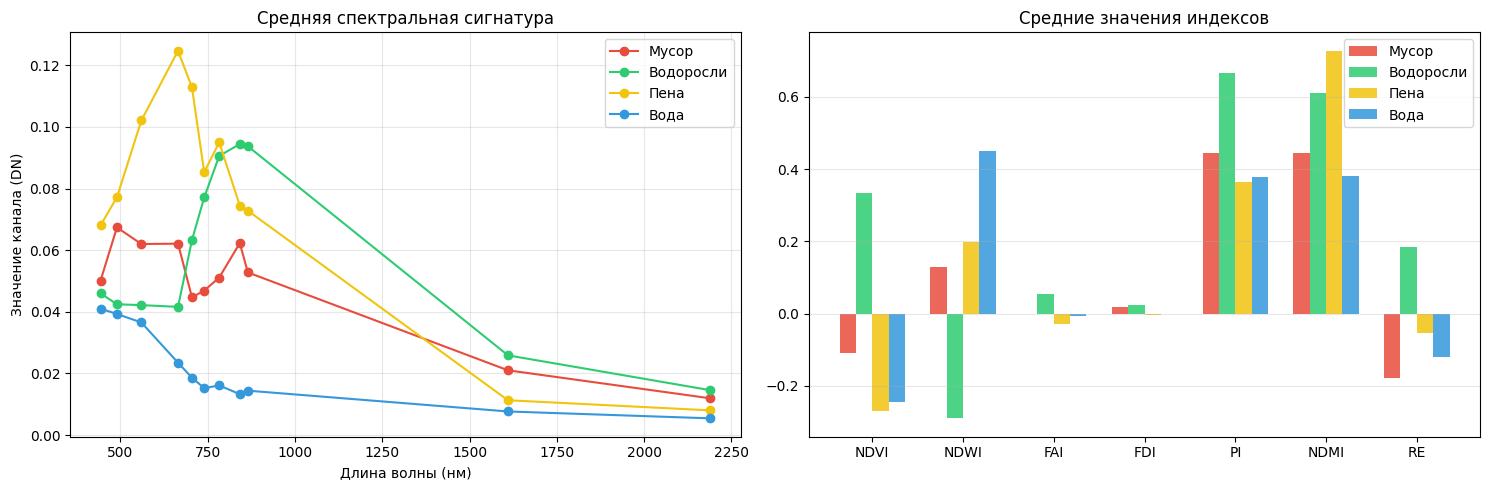

In [18]:
# Средние значения признаков по классам в train
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Каналы Sentinel-2
BAND_WL = [443, 490, 560, 665, 705, 740, 783, 842, 865, 1610, 2190]
ax = axes[0]
for cls in range(4):
    mask = y_train == cls
    if mask.sum() == 0:
        continue
    idx = np.random.choice(np.where(mask)[0], min(10000, mask.sum()), replace=False)
    mean_spec = X_train[idx, :11].mean(axis=0)
    ax.plot(BAND_WL, mean_spec, marker="o", label=TARGET_NAMES[cls],
            color=list(CLASS_COLORS.values())[cls])
ax.set_xlabel("Длина волны (нм)")
ax.set_ylabel("Значение канала (DN)")
ax.set_title("Средняя спектральная сигнатура")
ax.legend(); ax.grid(alpha=0.3)

# Спектральные индексы
idx_labels = ["NDVI","NDWI","FAI","FDI","PI","NDMI","RE"]
ax = axes[1]
bar_width = 0.18
x = np.arange(len(idx_labels))
for i, cls in enumerate(range(4)):
    mask = y_train == cls
    if mask.sum() == 0:
        continue
    idx = np.random.choice(np.where(mask)[0], min(10000, mask.sum()), replace=False)
    means = X_train[idx, 11:].mean(axis=0)
    ax.bar(x + i * bar_width, means, width=bar_width,
           label=TARGET_NAMES[cls], color=CLASS_COLORS[cls], alpha=0.85)
ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(idx_labels)
ax.set_title("Средние значения индексов")
ax.legend(); ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# Дисбаланс классов — насколько он велик?
cnt = Counter(y_train.tolist())
max_cnt = max(cnt.values())
min_cnt = min(cnt.values())

print("Итоговая статистика датасета:")
print(f"  {'Класс':<12}  {'Train':>10}  {'Val':>8}  {'Test':>8}")
print("  " + "-" * 44)
cnt_val  = Counter(y_val.tolist())
cnt_test = Counter(y_test.tolist())
for cls in range(4):
    print(f"  {TARGET_NAMES[cls]:<12}  {cnt.get(cls,0):>10,}  {cnt_val.get(cls,0):>8,}  {cnt_test.get(cls,0):>8,}")

print(f"\n  Дисбаланс (max/min): {max_cnt // min_cnt:.0f}×")
print(f"  Совет: использовать class_weight='balanced' или oversample класс 'Мусор'")

Итоговая статистика датасета:
  Класс              Train       Val      Test
  --------------------------------------------
  Мусор              1,943     1,075       381
  Водоросли          2,684     1,644     1,690
  Пена             168,187   126,576    95,543
  Вода             174,166    57,774    56,056

  Дисбаланс (max/min): 89×
  Совет: использовать class_weight='balanced' или oversample класс 'Мусор'


In [20]:
print("=" * 50)
print("ДАТАСЕТ ГОТОВ")
print("=" * 50)
print(f"  pixels_train.npz  — {X_train.shape[0]:,} пикселей")
print(f"  pixels_val.npz    — {X_val.shape[0]:,} пикселей")
print(f"  pixels_test.npz   — {X_test.shape[0]:,} пикселей")
print(f"  patch_X_train.npy — {len(pX_train)} патчей")
print()
print("Далее: model_training.ipynb")

ДАТАСЕТ ГОТОВ
  pixels_train.npz  — 346,980 пикселей
  pixels_val.npz    — 187,069 пикселей
  pixels_test.npz   — 153,670 пикселей
  patch_X_train.npy — 694 патчей

Далее: model_training.ipynb
